# 📊 Small-Cap Mutual Fund Portfolio Analysis
### Top 10 Small-Cap Funds by AUM — Nov 2025 to Apr 2026
**Objective:** Identify common holdings and track whether fund managers are consistently accumulating or reducing stocks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

FILE = 'Portfolio_SmallCap_India_Top10.xlsx'
FUNDS = ['HSBC', 'Nippon India', 'HDFC', 'SBI', 'Quant', 'AXIS', 'Kotak', 'Franklin', 'DSP', 'Bandhan']
MONTHS_ORDER = ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']

## 🔧 Data Loading & Preprocessing

In [2]:
# Non-stock rows to exclude
NON_STOCK = ['AUM', 'Cash and Other Receivables', 'NIFTY', 'MIDCAPNIFTY 30/12/2025']

raw_data = {}   # fund -> DataFrame (Security Name as index, month columns)
aum_data = {}   # fund -> dict of month -> AUM

for fund in FUNDS:
    df = pd.read_excel(FILE, sheet_name=fund, na_values=['-'])
    
    # Rename date columns to 'YYYY-MM' strings
    new_cols = ['Security Name']
    for c in df.columns[1:]:
        if hasattr(c, 'strftime'):
            new_cols.append(c.strftime('%Y-%m'))
        else:
            new_cols.append(str(c))
    df.columns = new_cols
    
    # Extract AUM row
    aum_row = df[df['Security Name'] == 'AUM']
    if not aum_row.empty:
        aum_data[fund] = aum_row.iloc[0, 1:].to_dict()
    
    # Remove non-stock rows
    df = df[~df['Security Name'].isin(NON_STOCK)].copy()
    df = df.dropna(subset=['Security Name'])
    df['Security Name'] = df['Security Name'].str.strip()
    df = df.set_index('Security Name')
    
    # Keep only MONTHS_ORDER columns that exist
    month_cols = [m for m in MONTHS_ORDER if m in df.columns]
    df = df[month_cols]
    
    # Convert to numeric
    df = df.apply(pd.to_numeric, errors='coerce')
    raw_data[fund] = df

print('✅ Data loaded for funds:', list(raw_data.keys()))
print('\n📅 Months available per fund:')
for f, d in raw_data.items():
    print(f'  {f}: {list(d.columns)}')

✅ Data loaded for funds: ['HSBC', 'Nippon India', 'HDFC', 'SBI', 'Quant', 'AXIS', 'Kotak', 'Franklin', 'DSP', 'Bandhan']

📅 Months available per fund:
  HSBC: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  Nippon India: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  HDFC: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  SBI: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  Quant: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  AXIS: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  Kotak: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  Franklin: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  DSP: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
  Bandhan: ['2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']


---
## Analysis 1 — Common Holdings Across Funds
**Question:** Which stocks are held by how many small-cap funds at the same time?

📋 Holdings Distribution Table — Apr 2026


,# Funds Holding,Stock Count,Stocks
0,3,9,"Hexaware Technologies Ltd, eClerx Services Limited, Navin Fluorine International Limited, Amber Enterprises India Li..."
1,2,52,"Dhanuka Agritech Ltd, JK Cement Ltd, PVR Inox Ltd, Aditya Infotech Ltd, Angel One Ltd, Kajaria Ceramics Ltd, Ratnama..."
2,1,506,"The Federal Bank Limited, Mtar Technologies Limited, GE Vernova T&D India Limited, APAR INDUSTRIES LTD, Paradeep Pho..."


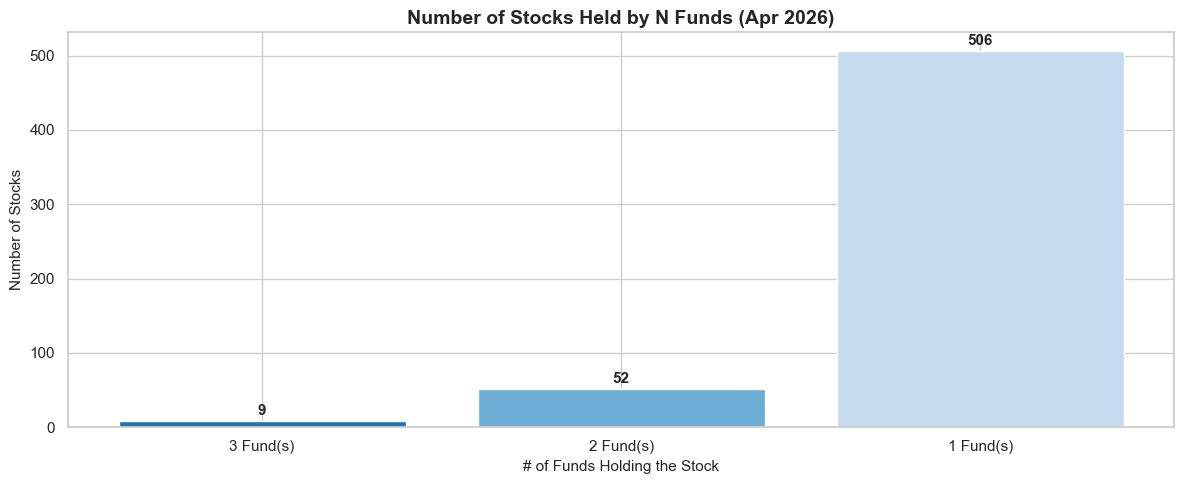

In [3]:
# For each stock, count how many funds hold it in Apr-26 (latest month)
LATEST = '2026-04'

stock_fund_count = {}
for fund, df in raw_data.items():
    if LATEST in df.columns:
        held = df[LATEST].dropna()
        held = held[held > 0]
        for stock in held.index:
            stock_fund_count[stock] = stock_fund_count.get(stock, 0) + 1

count_series = pd.Series(stock_fund_count).sort_values(ascending=False)

# Build table: rows = stocks, col = # of funds (1 to 10)
max_funds = 10
common_table_rows = []
for n_funds in range(max_funds, 0, -1):
    stocks_at_n = count_series[count_series == n_funds].index.tolist()
    common_table_rows.append({'# Funds Holding': n_funds, 'Stock Count': len(stocks_at_n), 'Stocks': ', '.join(stocks_at_n)})

common_table = pd.DataFrame(common_table_rows)
common_table = common_table[common_table['Stock Count'] > 0].reset_index(drop=True)

print('📋 Holdings Distribution Table — Apr 2026')
print('=' * 80)
pd.set_option('display.max_colwidth', 120)
display(common_table)

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(common_table['# Funds Holding'].astype(str) + ' Fund(s)', common_table['Stock Count'],
              color=sns.color_palette('Blues_r', len(common_table)))
ax.bar_label(bars, padding=2, fontsize=11, fontweight='bold')
ax.set_title('Number of Stocks Held by N Funds (Apr 2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('# of Funds Holding the Stock', fontsize=11)
ax.set_ylabel('Number of Stocks', fontsize=11)
plt.tight_layout()
plt.show()

---
## Analysis 2 — Top 10 Common Holdings (Apr-26 to Nov-25)
**Question:** Which stocks appear repeatedly in the top 10 holdings across funds?

🏆 Top 20 Stocks by Top-10 Appearances (Nov-25 to Apr-26, All Funds)


,Stock,Top-10 Appearances (All Funds × All Months)
1,eClerx Services Limited,13
2,Aster DM Healthcare Ltd,12
3,Krishna Institute Of Medical Sciences Limited,9
4,City Union Bank Limited,9
5,Kajaria Ceramics Ltd,9
6,Karur Vysya Bank Limited,8
7,State Bank of India,7
8,Aster DM Healthcare Limited,7
9,Multi Commodity Exchange of India Ltd,6
10,Ather Energy Ltd.,6


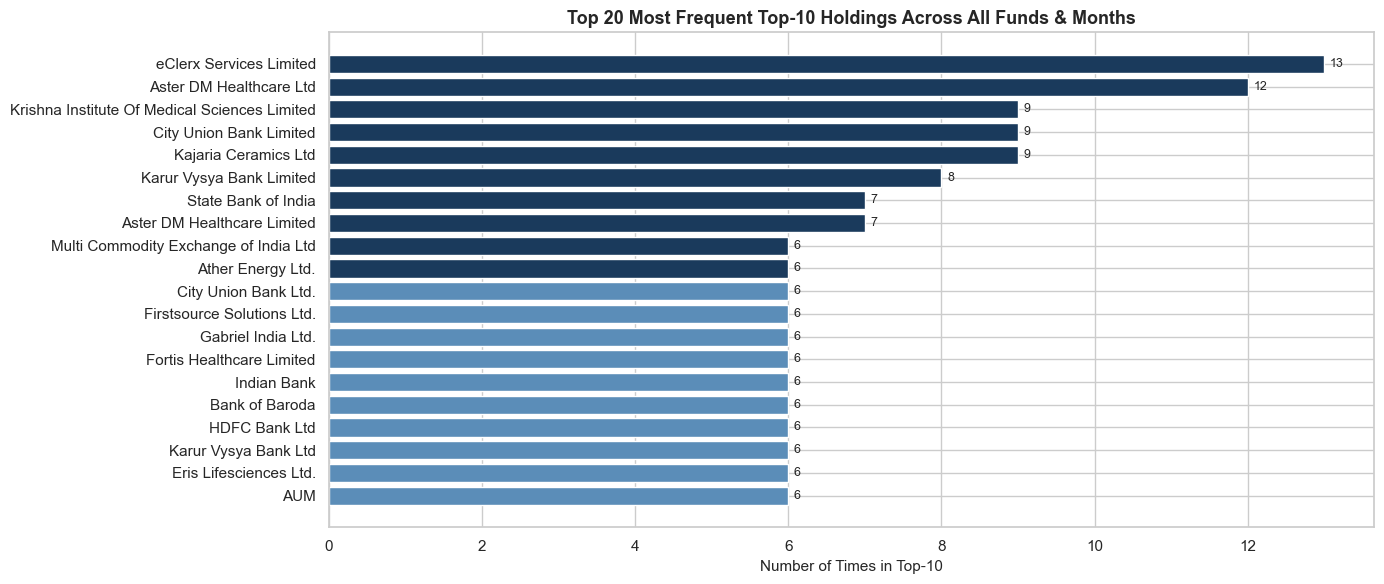

In [5]:
# Count appearances in top-10 holdings across all funds and all months
top10_appearances = {}

for fund, df in raw_data.items():
    for month in MONTHS_ORDER:
        if month in df.columns:
            top10 = df[month].dropna().nlargest(10).index.tolist()
            for stock in top10:
                top10_appearances[stock] = top10_appearances.get(stock, 0) + 1

top10_series = pd.Series(top10_appearances).sort_values(ascending=False).head(20)

# Table
top10_df = pd.DataFrame({'Stock': top10_series.index, 'Top-10 Appearances (All Funds × All Months)': top10_series.values})
top10_df.index = range(1, len(top10_df)+1)
print('🏆 Top 20 Stocks by Top-10 Appearances (Nov-25 to Apr-26, All Funds)')
display(top10_df.head(20))

# Chart
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#1a3a5c' if i < 10 else '#5b8db8' for i in range(len(top10_series))]
bars = ax.barh(top10_series.index[::-1], top10_series.values[::-1], color=colors[::-1])
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title('Top 20 Most Frequent Top-10 Holdings Across All Funds & Months', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Times in Top-10', fontsize=11)
plt.tight_layout()
plt.show()

---
## Analysis 3 — Net Buy / Net Sell by Fund
**Question:** Which stocks did each fund increase or reduce over Nov-25 to Apr-26?

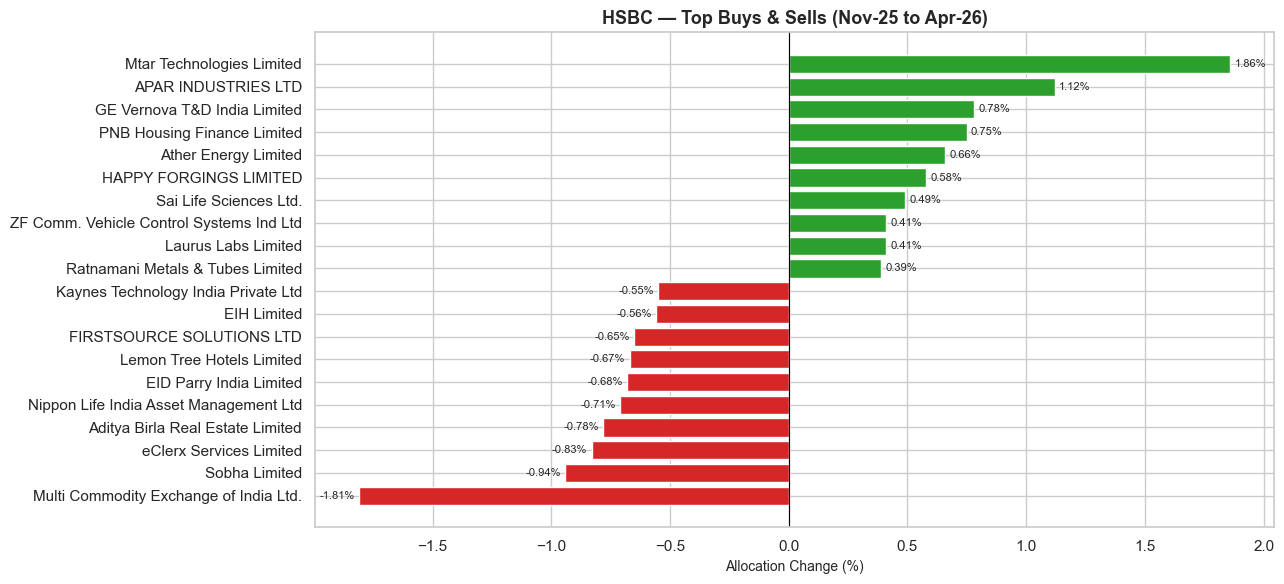

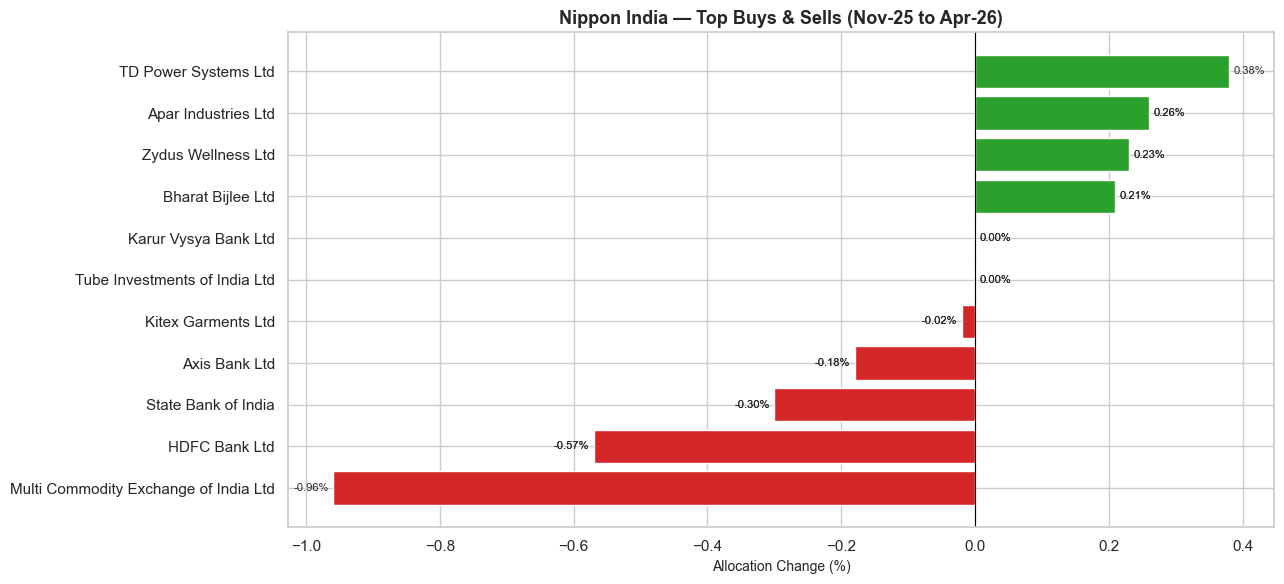

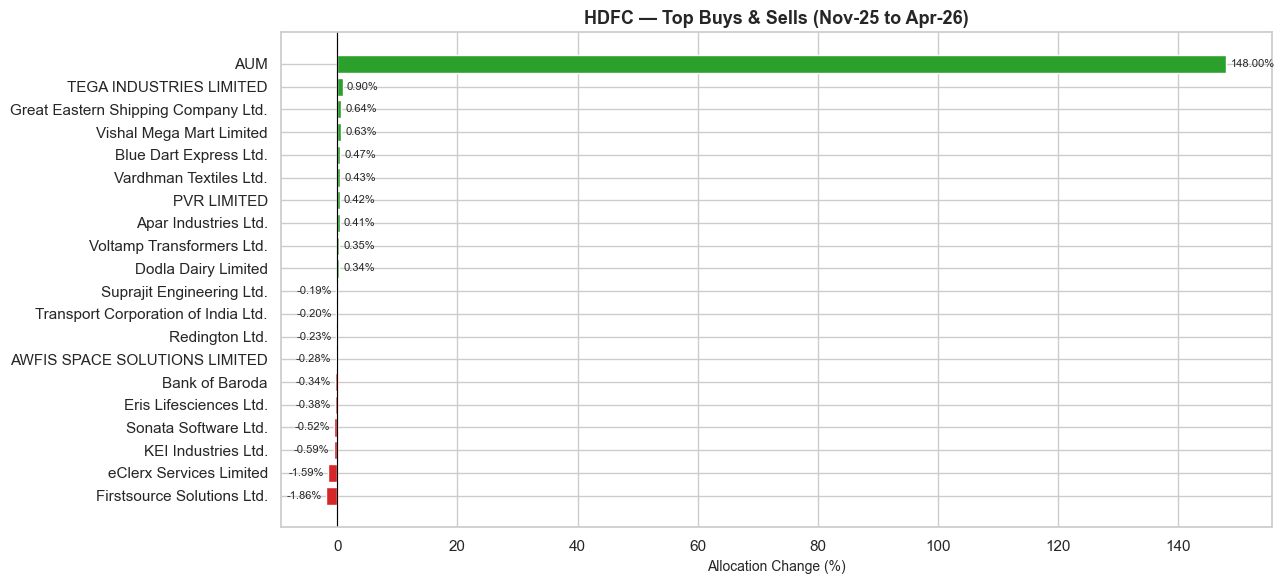

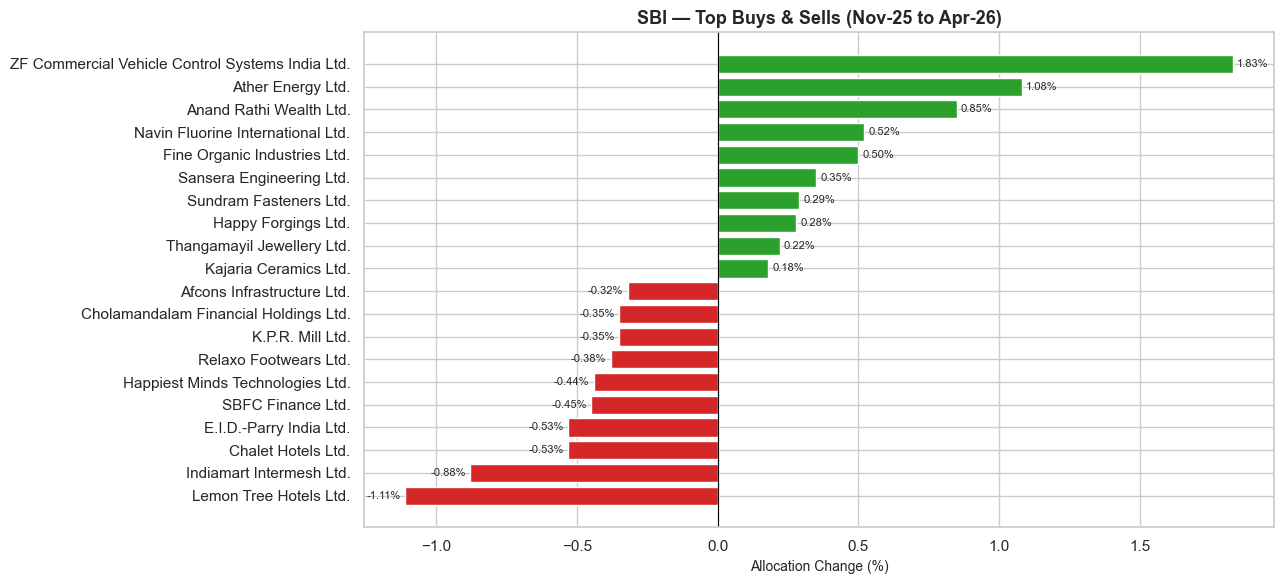

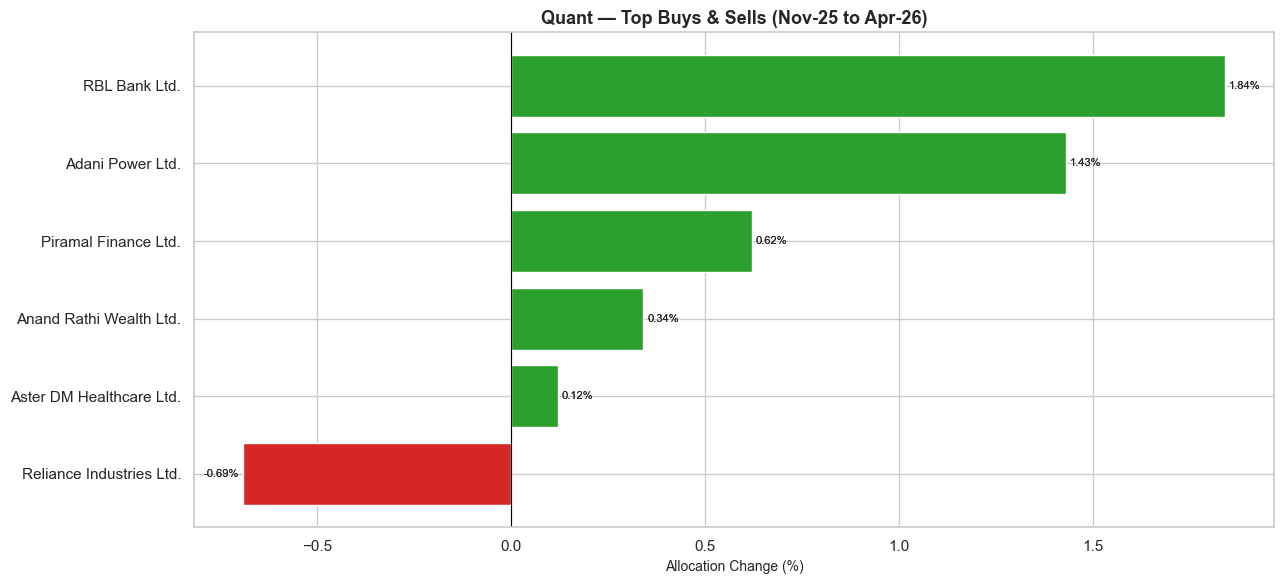

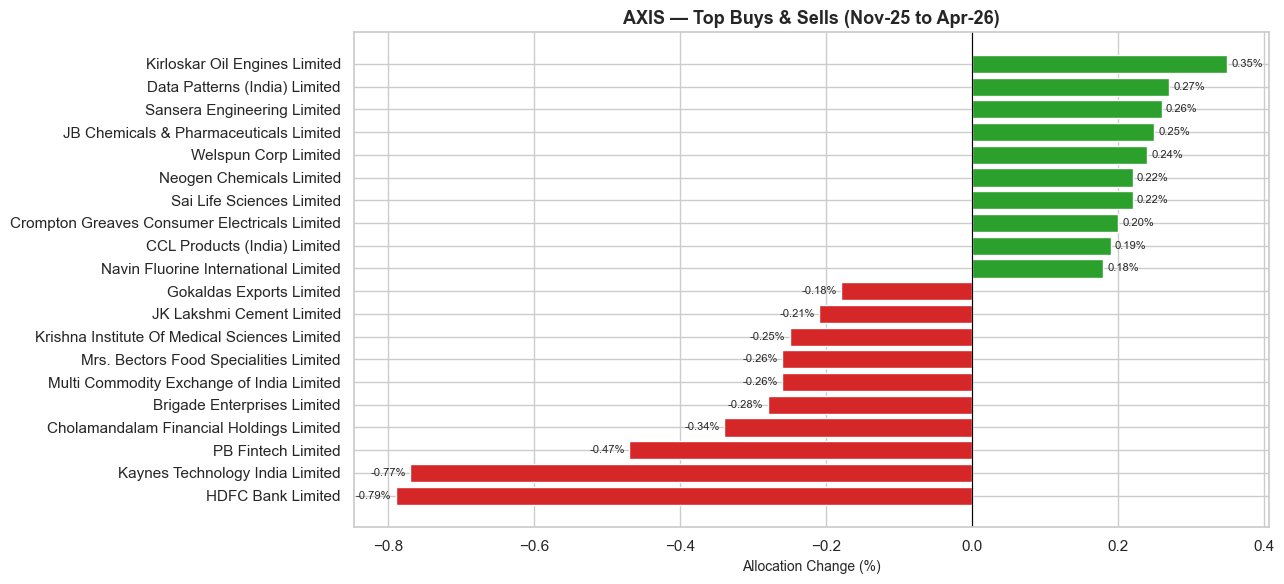

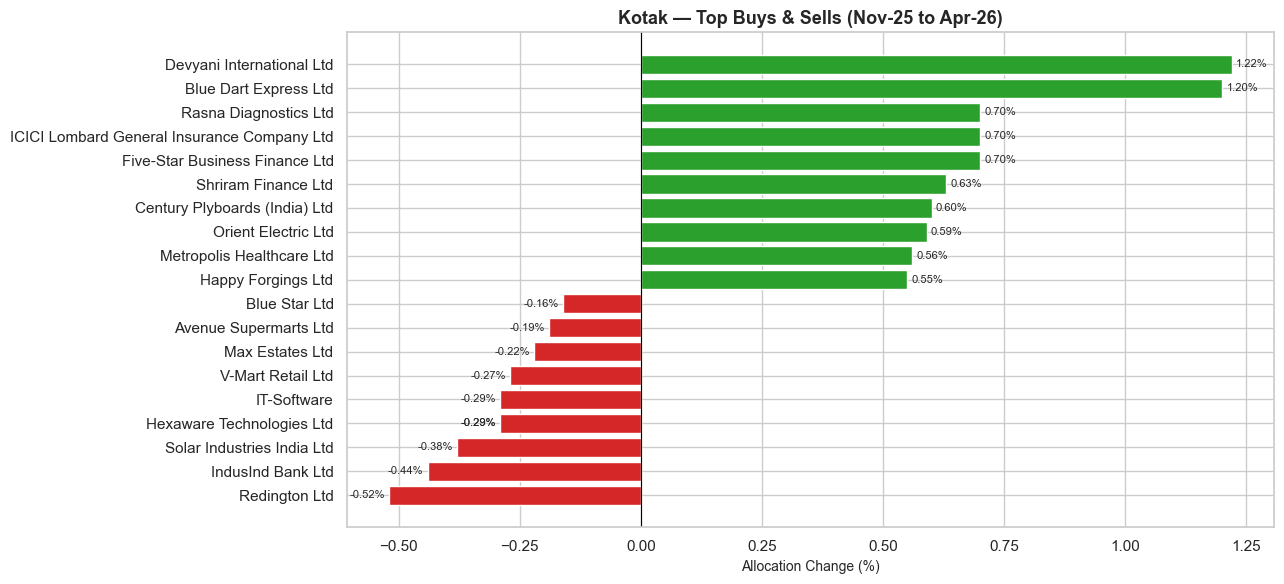

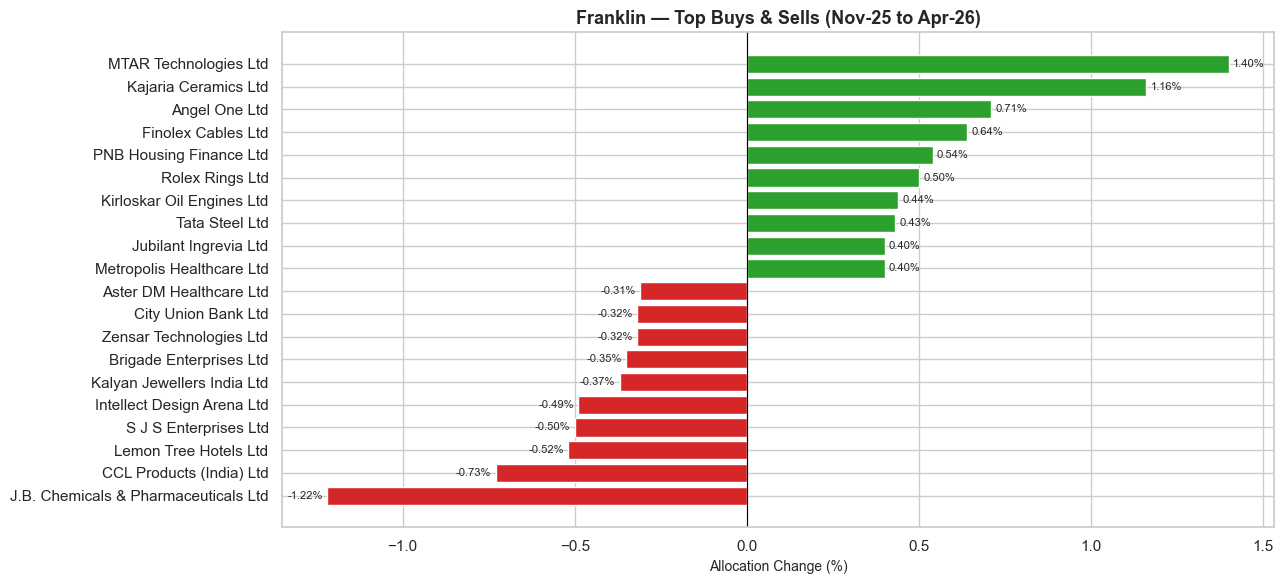

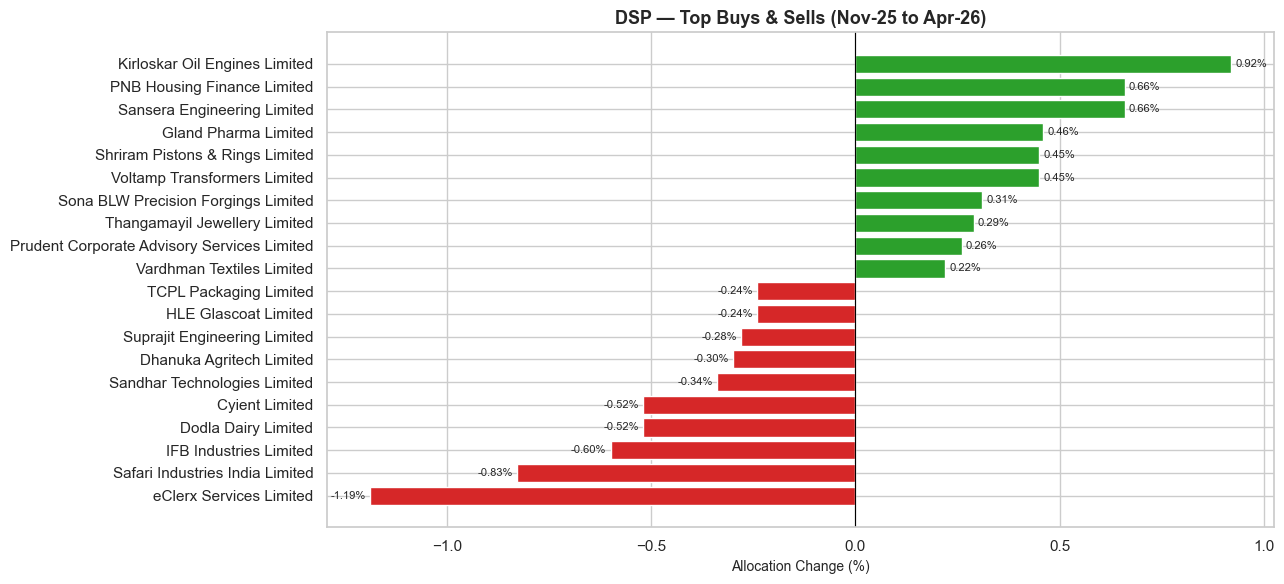

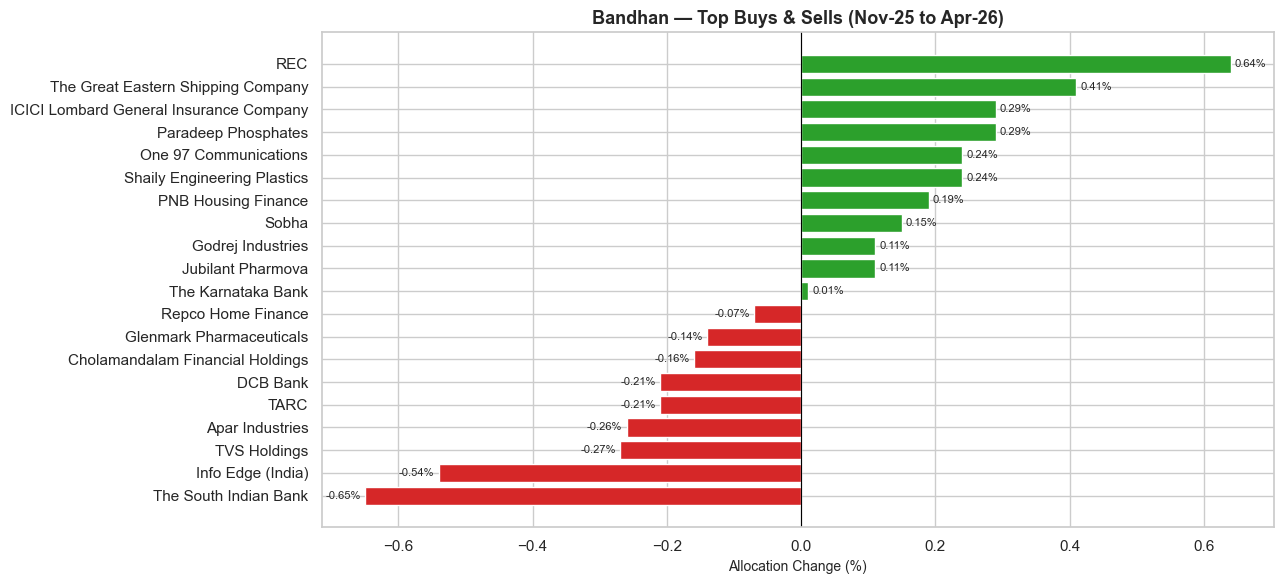

In [6]:
START_MONTH = '2025-11'
END_MONTH = '2026-04'

for fund, df in raw_data.items():
    if START_MONTH not in df.columns or END_MONTH not in df.columns:
        print(f'⚠️ Skipping {fund} — missing start or end month')
        continue
    
    change = df[END_MONTH] - df[START_MONTH]
    change = change.dropna()
    
    # Top 10 buys & sells
    buys = change.nlargest(10)
    sells = change.nsmallest(10)
    combined = pd.concat([buys, sells]).sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(13, 6))
    colors = ['#d62728' if v < 0 else '#2ca02c' for v in combined.values]
    bars = ax.barh(combined.index, combined.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=8)
    ax.set_title(f'{fund} — Top Buys & Sells (Nov-25 to Apr-26)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Allocation Change (%)', fontsize=10)
    plt.tight_layout()
    plt.show()

---
## Analysis 4 — Buy-Month Count
**Question:** Out of 5 month-to-month changes, how many months did allocation increase for each stock?

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

buy_month_data = []

for fund, df in raw_data.items():

    # Convert "-" to NaN and make values numeric
    df = df.replace("-", np.nan)

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # IMPORTANT: if same stock appears more than once, combine it
    df = df.groupby(df.index).sum(numeric_only=True)

    months = [m for m in MONTHS_ORDER if m in df.columns]

    if len(months) < 2:
        continue

    for stock in df.index:
        series = df.loc[stock, months]

        # Ensure it is numeric
        series = pd.to_numeric(series, errors="coerce")

        # Keep only months where stock exists
        series = series.dropna()

        if len(series) < 2:
            continue

        month_changes = series.diff().dropna()

        buy_months = int((month_changes > 0).sum())
        sell_months = int((month_changes < 0).sum())
        no_change_months = int((month_changes == 0).sum())

        buy_month_data.append({
            "Fund": fund,
            "Stock": stock,
            "Buy Months": buy_months,
            "Sell Months": sell_months,
            "No Change Months": no_change_months,
            "Total Periods": len(month_changes),
            "Net Change": round(series.iloc[-1] - series.iloc[0], 2),
            "Start Allocation": series.iloc[0],
            "End Allocation": series.iloc[-1]
        })

bm_df = pd.DataFrame(buy_month_data)

bm_agg = bm_df.groupby("Stock").agg(
    Funds_Tracked=("Fund", "count"),
    Avg_Buy_Months=("Buy Months", "mean"),
    Avg_Sell_Months=("Sell Months", "mean"),
    Avg_Net_Change=("Net Change", "mean")
).round(2).reset_index()

bm_agg = bm_agg[bm_agg["Funds_Tracked"] >= 3]
bm_agg = bm_agg.sort_values(["Avg_Buy_Months", "Avg_Net_Change"], ascending=False)

print("📈 Buy-Month Count — Stocks held by ≥3 Funds")
display(bm_agg.head(25).reset_index(drop=True))

📈 Buy-Month Count — Stocks held by ≥3 Funds


,Stock,Funds_Tracked,Avg_Buy_Months,Avg_Sell_Months,Avg_Net_Change
0,PNB Housing Finance Limited,3,3.33,1.33,0.78
1,Navin Fluorine International Limited,3,3.00,1.33,0.44
2,Rolex Rings Limited,3,2.67,1.33,0.27
3,Karur Vysya Bank Ltd,3,2.67,2.33,-0.05
4,Axis Bank Ltd,3,2.00,2.00,0.07
5,Amber Enterprises India Limited,3,2.00,2.33,0.05
6,Aster DM Healthcare Ltd,3,1.67,2.33,0.06
7,eClerx Services Limited,3,1.33,3.67,-1.20
8,Sudarshan Chemical Industries Limited,3,1.00,3.33,-0.10


---
## Analysis 5 — Accumulation Score
**Question:** Which stocks show consistent accumulation? Score = Buy Months − Sell Months

⚡ Accumulation Score (Stocks held by ≥3 Funds)
   Score = Sum of (Buy Months - Sell Months) across all funds
   Max possible score = 5 × 10 = 50 | Min = -50


,Stock,Funds_Tracked,Total_Accum_Score,Avg_Accum_Score
0,PNB Housing Finance Limited,3,6,2.00
1,Navin Fluorine International Limited,3,5,1.67
2,Rolex Rings Limited,3,4,1.33
3,Karur Vysya Bank Ltd,3,1,0.33
4,Axis Bank Ltd,3,0,0.00
5,Amber Enterprises India Limited,3,-1,-0.33
6,Aster DM Healthcare Ltd,3,-2,-0.67
7,Sudarshan Chemical Industries Limited,3,-7,-2.33
8,eClerx Services Limited,3,-7,-2.33


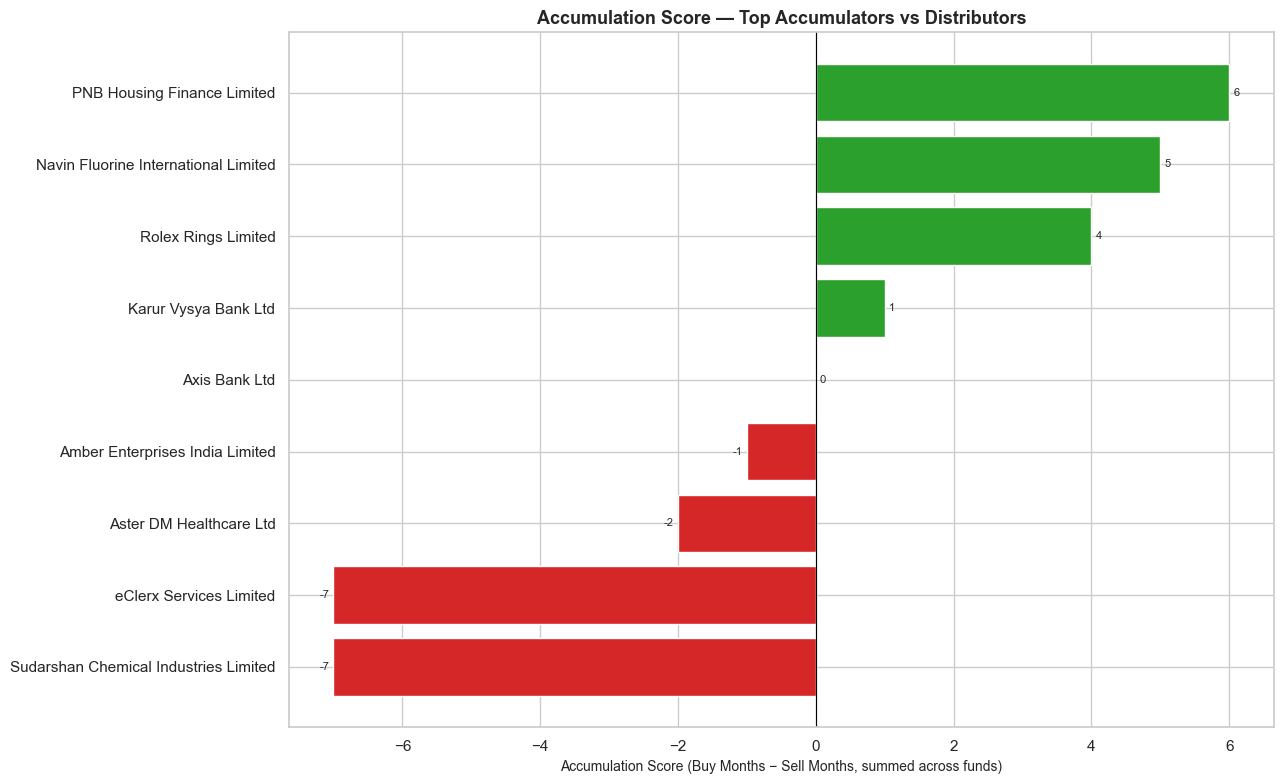

In [17]:
# Use bm_df from Analysis 4
bm_df['Accumulation Score'] = bm_df['Buy Months'] - bm_df['Sell Months']

acc_agg = bm_df.groupby('Stock').agg(
    Funds_Tracked=('Fund', 'count'),
    Total_Accum_Score=('Accumulation Score', 'sum'),
    Avg_Accum_Score=('Accumulation Score', 'mean')
).round(2).reset_index()

acc_agg = acc_agg[acc_agg['Funds_Tracked'] >= 3]
acc_agg = acc_agg.sort_values('Total_Accum_Score', ascending=False).reset_index(drop=True)

print('⚡ Accumulation Score (Stocks held by ≥3 Funds)')
print('   Score = Sum of (Buy Months - Sell Months) across all funds')
print('   Max possible score = 5 × 10 = 50 | Min = -50')
display(acc_agg.head(25))

# Chart
top_acc = acc_agg.head(20)
bot_acc = acc_agg.tail(10)
plot_acc = pd.concat([top_acc, bot_acc]).drop_duplicates('Stock').sort_values('Total_Accum_Score')

fig, ax = plt.subplots(figsize=(13, 8))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in plot_acc['Total_Accum_Score']]
bars = ax.barh(plot_acc['Stock'], plot_acc['Total_Accum_Score'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
ax.set_title('Accumulation Score — Top Accumulators vs Distributors', fontsize=13, fontweight='bold')
ax.set_xlabel('Accumulation Score (Buy Months − Sell Months, summed across funds)', fontsize=10)
plt.tight_layout()
plt.show()

---
## Analysis 6 — New Entries & Exits
**Question:** Which stocks entered or exited each fund's portfolio during Nov-25 to Apr-26?

In [18]:
entry_exit_summary = []

for fund, df in raw_data.items():
    if START_MONTH not in df.columns or END_MONTH not in df.columns:
        continue
    held_start = set(df[START_MONTH].dropna()[df[START_MONTH].dropna() > 0].index)
    held_end   = set(df[END_MONTH].dropna()[df[END_MONTH].dropna() > 0].index)
    
    new_entries = held_end - held_start
    exits = held_start - held_end
    
    for s in new_entries:
        entry_exit_summary.append({'Fund': fund, 'Stock': s, 'Action': 'New Entry'})
    for s in exits:
        entry_exit_summary.append({'Fund': fund, 'Stock': s, 'Action': 'Exit'})

ee_df = pd.DataFrame(entry_exit_summary)

# Show fund-wise summary
print('🚀 New Entries & Exits per Fund (Nov-25 → Apr-26)')
print('=' * 70)
for fund in FUNDS:
    fund_ee = ee_df[ee_df['Fund'] == fund]
    entries = fund_ee[fund_ee['Action'] == 'New Entry']['Stock'].tolist()
    exits_list = fund_ee[fund_ee['Action'] == 'Exit']['Stock'].tolist()
    print(f'\n📁 {fund}')
    print(f'  ✅ New Entries ({len(entries)}): {", ".join(entries) if entries else "None"}')
    print(f'  ❌ Exits ({len(exits_list)}):      {", ".join(exits_list) if exits_list else "None"}')

# Cross-fund: which stocks were new entries in the most funds?
print('\n\n🔥 Stocks Newly Entered in Multiple Funds:')
multi_entry = ee_df[ee_df['Action'] == 'New Entry'].groupby('Stock')['Fund'].count().sort_values(ascending=False)
display(multi_entry[multi_entry > 1].reset_index().rename(columns={'Fund': 'Number of Funds Entered'}))

print('\n⚰️ Stocks Exited from Multiple Funds:')
multi_exit = ee_df[ee_df['Action'] == 'Exit'].groupby('Stock')['Fund'].count().sort_values(ascending=False)
display(multi_exit[multi_exit > 1].reset_index().rename(columns={'Fund': 'Number of Funds Exited'}))

🚀 New Entries & Exits per Fund (Nov-25 → Apr-26)

📁 HSBC
  ✅ New Entries (10): Senores Pharmaceuticals Limited, Kirloskar Oil Engines Ltd, BSE Ltd, CRAFTSMAN AUTOMATION LIMITED, Godfrey Phillips India Limited, National Aluminium Company Limited, Krishna Institute of Medical Science Ltd, Angel One Limited, Navin Fluorine International Limited, Piramal Finance Ltd
  ❌ Exits (8):      JK TYRE & INDUSTRIES LTD, Brigade Enterprises Limited, Grindwell Norton Limited, UTI ASSET MANAGEMENT COMPANY LTD, Dixon Technologies (India) Limited, Suzlon Energy Limited, Balrampur Chini Mills Limited, HG Infra Engineering Limited

📁 Nippon India
  ✅ New Entries (5): Eimco Elecon Ltd, Voltamp Transformers Ltd, Whirlpool of India Ltd, Punjab National Bank, NLC India Ltd
  ❌ Exits (4):      ICICI Ltd, Kasco Industries Ltd, Pilani Investment Ltd, Cox Services Ltd

📁 HDFC
  ✅ New Entries (6): Brainbees Solutions Limited (FirstCry), Wakefit Innovations Limited, JSW Dulux Limited, Vijaya Diagnostic Centre Limit

,Stock,Number of Funds Entered



⚰️ Stocks Exited from Multiple Funds:


,Stock,Number of Funds Exited


---
## Analysis 7 — Strong Buy / Strong Sell Stocks
**Question:** Which stocks saw large allocation changes (threshold ≥ ±1 percentage point)?

In [19]:
THRESHOLD = 1.0  # percentage point

strong_signals = []
for fund, df in raw_data.items():
    if START_MONTH not in df.columns or END_MONTH not in df.columns:
        continue
    change = (df[END_MONTH] - df[START_MONTH]).dropna()
    strong = change[change.abs() >= THRESHOLD]
    for stock, val in strong.items():
        strong_signals.append({
            'Fund': fund, 'Stock': stock,
            'Nov-25 (%)': df.loc[stock, START_MONTH] if START_MONTH in df.columns else np.nan,
            'Apr-26 (%)': df.loc[stock, END_MONTH] if END_MONTH in df.columns else np.nan,
            'Change (pp)': round(val, 2),
            'Signal': '🟢 Strong Buy' if val > 0 else '🔴 Strong Sell'
        })

ss_df = pd.DataFrame(strong_signals).sort_values('Change (pp)', ascending=False)

print(f'🎯 Strong Buy / Sell Signals (|Change| ≥ {THRESHOLD} pp)')
print('\n🟢 TOP STRONG BUYS:')
display(ss_df[ss_df['Change (pp)'] >= THRESHOLD].head(20).reset_index(drop=True))

print('\n🔴 TOP STRONG SELLS:')
display(ss_df[ss_df['Change (pp)'] <= -THRESHOLD].sort_values('Change (pp)').head(20).reset_index(drop=True))

# Stocks with strong buy signal from multiple funds
print('\n🏆 Stocks with Strong Buy from Multiple Funds:')
multi_strong_buy = ss_df[ss_df['Change (pp)'] >= THRESHOLD].groupby('Stock')['Fund'].count().sort_values(ascending=False)
display(multi_strong_buy[multi_strong_buy > 1].reset_index().rename(columns={'Fund': 'Funds with Strong Buy'}))

🎯 Strong Buy / Sell Signals (|Change| ≥ 1.0 pp)

🟢 TOP STRONG BUYS:


,Fund,Stock,Nov-25 (%),Apr-26 (%),Change (pp),Signal
0,HDFC,AUM,38020.00,38168.00,148.00,🟢 Strong Buy
1,HSBC,Mtar Technologies Limited,1.22,3.08,1.86,🟢 Strong Buy
2,Quant,RBL Bank Ltd.,3.93,5.77,1.84,🟢 Strong Buy
3,SBI,ZF Commercial Vehicle Control Systems India Ltd.,0.94,2.77,1.83,🟢 Strong Buy
4,Quant,Adani Power Ltd.,2.95,4.38,1.43,🟢 Strong Buy
5,Franklin,MTAR Technologies Ltd,1.01,2.41,1.40,🟢 Strong Buy
6,Kotak,Devyani International Ltd,0.13,1.35,1.22,🟢 Strong Buy
7,Kotak,Blue Dart Express Ltd,0.13,1.33,1.20,🟢 Strong Buy
8,Franklin,Kajaria Ceramics Ltd,1.11,2.27,1.16,🟢 Strong Buy
9,HSBC,APAR INDUSTRIES LTD,0.92,2.04,1.12,🟢 Strong Buy



🔴 TOP STRONG SELLS:


,Fund,Stock,Nov-25 (%),Apr-26 (%),Change (pp),Signal
0,HDFC,Firstsource Solutions Ltd.,5.03,3.17,-1.86,🔴 Strong Sell
1,HSBC,Multi Commodity Exchange of India Ltd.,3.26,1.45,-1.81,🔴 Strong Sell
2,HDFC,eClerx Services Limited,3.94,2.35,-1.59,🔴 Strong Sell
3,Franklin,J.B. Chemicals & Pharmaceuticals Ltd,1.90,0.68,-1.22,🔴 Strong Sell
4,DSP,eClerx Services Limited,2.96,1.77,-1.19,🔴 Strong Sell
5,SBI,Lemon Tree Hotels Ltd.,1.52,0.41,-1.11,🔴 Strong Sell



🏆 Stocks with Strong Buy from Multiple Funds:


,Stock,Funds with Strong Buy


---
## Analysis 8 — Fund Overlap Matrix
**Question:** Which funds have similar portfolios? Which provide real diversification?

📊 Fund Overlap Matrix — Common Stock Count (Apr-26)
  (Diagonal = total holdings of the fund)


,HSBC,Nippon India,HDFC,SBI,Quant,AXIS,Kotak,Franklin,DSP,Bandhan
HSBC,107,0,2,0,0,13,0,2,11,0
Nippon India,0,16,0,0,0,0,2,3,0,0
HDFC,2,0,85,4,0,3,0,0,4,0
SBI,0,0,4,64,2,0,0,0,0,0
Quant,0,0,0,2,10,0,0,0,0,0
AXIS,13,0,3,0,0,77,0,0,13,0
Kotak,0,2,0,0,0,0,76,13,0,0
Franklin,2,3,0,0,0,0,13,85,0,0
DSP,11,0,4,0,0,13,0,0,81,0
Bandhan,0,0,0,0,0,0,0,0,0,30


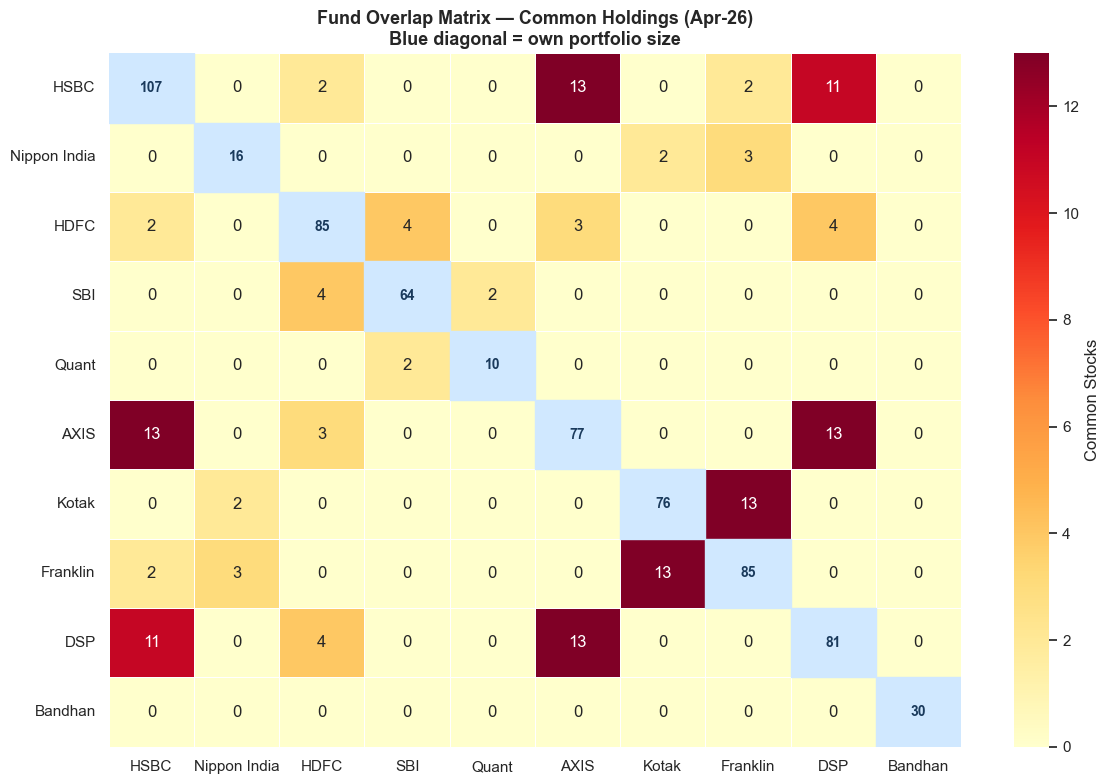


📐 Jaccard Similarity Matrix (% overlap — higher = more similar)


,HSBC,Nippon India,HDFC,SBI,Quant,AXIS,Kotak,Franklin,DSP,Bandhan
HSBC,100.0,0.0,1.1,0.0,0.0,7.6,0.0,1.1,6.2,0.0
Nippon India,0.0,100.0,0.0,0.0,0.0,0.0,2.2,3.1,0.0,0.0
HDFC,1.1,0.0,100.0,2.8,0.0,1.9,0.0,0.0,2.5,0.0
SBI,0.0,0.0,2.8,100.0,2.8,0.0,0.0,0.0,0.0,0.0
Quant,0.0,0.0,0.0,2.8,100.0,0.0,0.0,0.0,0.0,0.0
AXIS,7.6,0.0,1.9,0.0,0.0,100.0,0.0,0.0,9.0,0.0
Kotak,0.0,2.2,0.0,0.0,0.0,0.0,100.0,8.8,0.0,0.0
Franklin,1.1,3.1,0.0,0.0,0.0,0.0,8.8,100.0,0.0,0.0
DSP,6.2,0.0,2.5,0.0,0.0,9.0,0.0,0.0,100.0,0.0
Bandhan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0


In [20]:
# Overlap = number of common stocks held in Apr-26
holdings_apr = {}
for fund, df in raw_data.items():
    if END_MONTH in df.columns:
        held = set(df[END_MONTH].dropna()[df[END_MONTH].dropna() > 0].index)
        holdings_apr[fund] = held

fund_list = list(holdings_apr.keys())
n = len(fund_list)

# Common stock count matrix
overlap_matrix = pd.DataFrame(0, index=fund_list, columns=fund_list)
for f1, f2 in combinations(fund_list, 2):
    common = len(holdings_apr[f1] & holdings_apr[f2])
    overlap_matrix.loc[f1, f2] = common
    overlap_matrix.loc[f2, f1] = common
for f in fund_list:
    overlap_matrix.loc[f, f] = len(holdings_apr[f])

print('📊 Fund Overlap Matrix — Common Stock Count (Apr-26)')
print('  (Diagonal = total holdings of the fund)')
display(overlap_matrix)

# Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
mask = np.eye(n, dtype=bool)
sns.heatmap(overlap_matrix, annot=True, fmt='d', cmap='YlOrRd', mask=mask,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Common Stocks'})
# Diagonal with different color
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='#d0e8ff', zorder=3))
    ax.text(i + 0.5, i + 0.5, str(overlap_matrix.iloc[i, i]),
            ha='center', va='center', fontsize=10, fontweight='bold', color='#1a3a5c', zorder=4)
ax.set_title('Fund Overlap Matrix — Common Holdings (Apr-26)\nBlue diagonal = own portfolio size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Also: % overlap (Jaccard similarity)
jaccard_matrix = pd.DataFrame(0.0, index=fund_list, columns=fund_list)
for f1, f2 in combinations(fund_list, 2):
    union = len(holdings_apr[f1] | holdings_apr[f2])
    inter = len(holdings_apr[f1] & holdings_apr[f2])
    jaccard = inter / union if union > 0 else 0
    jaccard_matrix.loc[f1, f2] = round(jaccard * 100, 1)
    jaccard_matrix.loc[f2, f1] = round(jaccard * 100, 1)
for f in fund_list:
    jaccard_matrix.loc[f, f] = 100.0

print('\n📐 Jaccard Similarity Matrix (% overlap — higher = more similar)')
display(jaccard_matrix)

---
## Analysis 9 — Stock Popularity Ranking
**Question:** Which stocks are most popular among small-cap fund managers across all months?

🌟 Stock Popularity Ranking (Average # of Funds Holding — Nov-25 to Apr-26)


,Stock,Avg Funds Holding,Max Funds Holding
Rank,,,
1,eClerx Services Limited,3.0,3
2,Sudarshan Chemical Industries Limited,3.0,3
3,Axis Bank Ltd,3.0,3
4,Karur Vysya Bank Ltd,3.0,3
5,Navin Fluorine International Limited,2.5,3
6,PNB Housing Finance Limited,2.5,3
7,Rolex Rings Limited,2.3,3
8,Hexaware Technologies Ltd,2.3,3
9,Amber Enterprises India Limited,2.3,3


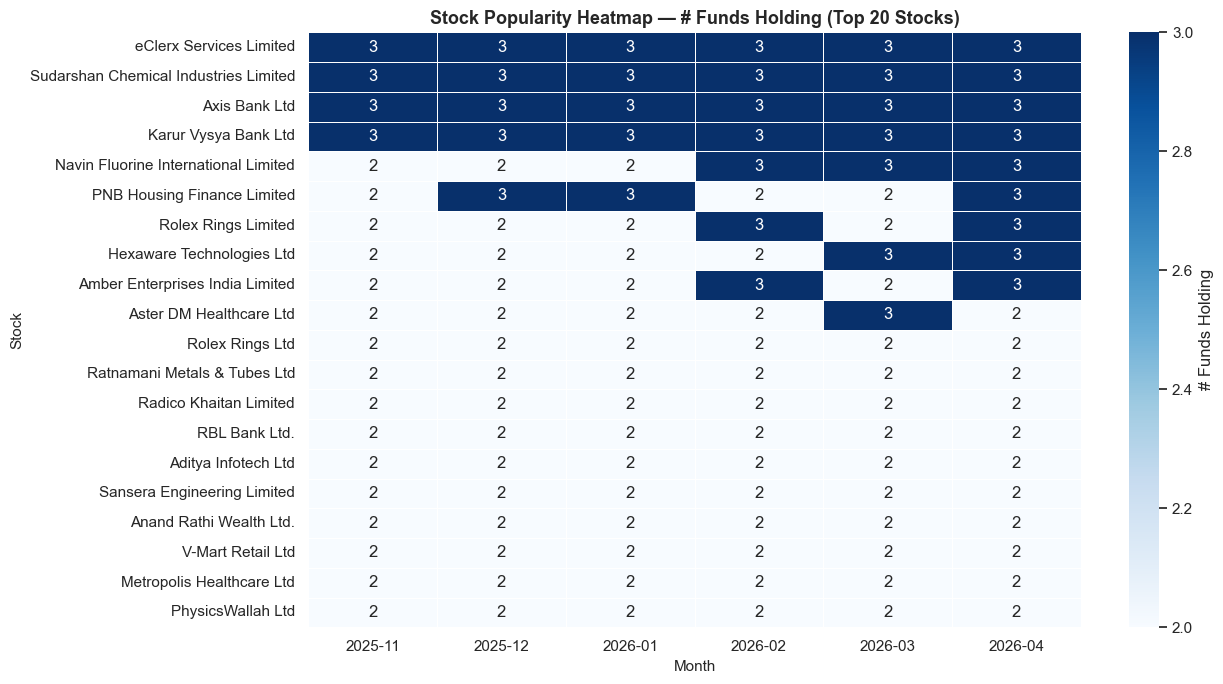

In [21]:
# Build monthly popularity: for each month, count how many funds hold each stock
popularity_records = []
for month in MONTHS_ORDER:
    month_counts = {}
    for fund, df in raw_data.items():
        if month in df.columns:
            held = df[month].dropna()
            held = held[held > 0]
            for stock in held.index:
                month_counts[stock] = month_counts.get(stock, 0) + 1
    for stock, cnt in month_counts.items():
        popularity_records.append({'Month': month, 'Stock': stock, 'Funds Holding': cnt})

pop_df = pd.DataFrame(popularity_records)

# Average popularity across all months
avg_pop = pop_df.groupby('Stock')['Funds Holding'].mean().sort_values(ascending=False)
max_pop = pop_df.groupby('Stock')['Funds Holding'].max()

pop_rank = pd.DataFrame({
    'Stock': avg_pop.index,
    'Avg Funds Holding': avg_pop.values.round(1),
    'Max Funds Holding': max_pop.reindex(avg_pop.index).values
}).reset_index(drop=True)
pop_rank.index = range(1, len(pop_rank)+1)
pop_rank.index.name = 'Rank'

print('🌟 Stock Popularity Ranking (Average # of Funds Holding — Nov-25 to Apr-26)')
display(pop_rank.head(30))

# Monthly popularity heatmap for top 20 stocks
top20_stocks = avg_pop.head(20).index.tolist()
pop_pivot = pop_df[pop_df['Stock'].isin(top20_stocks)].pivot_table(
    index='Stock', columns='Month', values='Funds Holding', fill_value=0)
pop_pivot = pop_pivot.reindex(columns=MONTHS_ORDER, fill_value=0)
pop_pivot = pop_pivot.loc[top20_stocks]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pop_pivot, annot=True, fmt='.0f', cmap='Blues', linewidths=0.4,
            ax=ax, cbar_kws={'label': '# Funds Holding'})
ax.set_title('Stock Popularity Heatmap — # Funds Holding (Top 20 Stocks)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Stock', fontsize=11)
plt.tight_layout()
plt.show()

---
## Analysis 10 — Concentration Analysis
**Question:** Which funds are more concentrated or more diversified?

🔍 Concentration Analysis — Apr-26 Snapshot
   HHI: Higher = More Concentrated | Lower = More Diversified


,Fund,Month,AUM (Cr),No. of Stocks,Top-10 Allocation (%),Total Equity Alloc (%),HHI (Concentration)
0,HDFC,2026-04,NaN,85,38192.74,38258.45,9952.8
1,Kotak,2026-04,"`17,416.48",82,126.27,199.50,2555.5
2,Quant,2026-04,30374.0,10,38.76,38.76,1301.5
3,DSP,2026-04,17906.0,81,29.33,91.66,195.3
4,SBI,2026-04,37150.0,64,27.96,86.19,224.1
5,Franklin,2026-04,13850.25,85,21.65,94.62,144.9
6,HSBC,2026-04,16392.14,107,20.33,98.45,127.2
7,AXIS,2026-04,27363.97,77,19.85,71.59,165.4
8,Bandhan,2026-04,25345.79,30,18.93,37.12,427.8
9,Nippon India,2026-04,72673.0,16,14.29,19.79,677.2


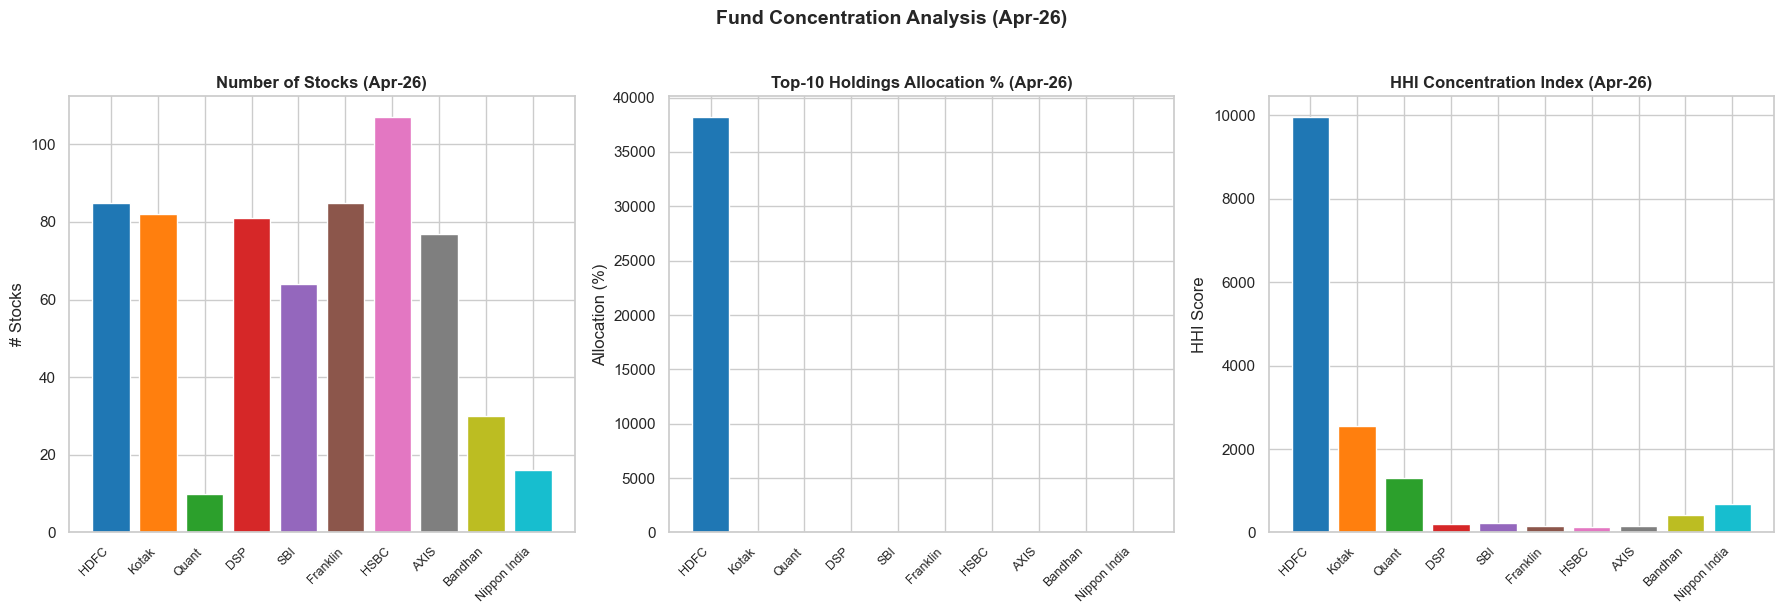

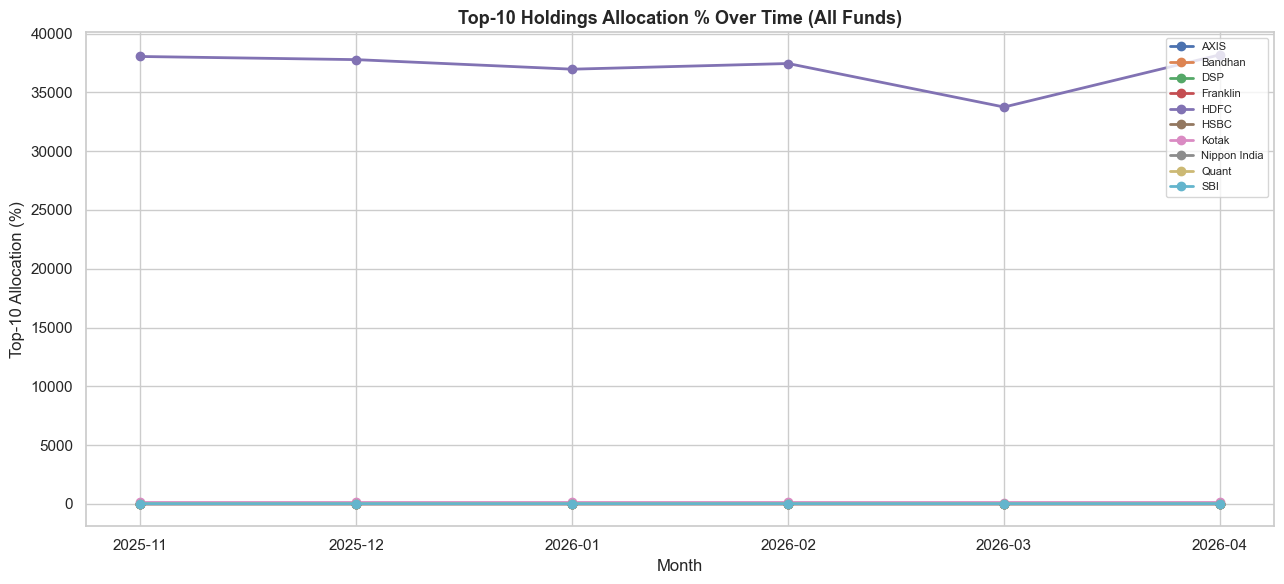

In [22]:
conc_data = []

for fund in FUNDS:
    df = raw_data[fund]
    
    for month in MONTHS_ORDER:
        if month not in df.columns:
            continue
        col = df[month].dropna()
        col = col[col > 0]
        
        if col.empty:
            continue
        
        total_alloc = col.sum()
        top10_alloc = col.nlargest(10).sum()
        n_stocks = len(col)
        
        # AUM
        aum_val = aum_data.get(fund, {}).get(month, np.nan)
        
        # HHI — Herfindahl-Hirschman Index (concentration)
        weights = col / total_alloc
        hhi = (weights ** 2).sum() * 10000  # scale to 0-10000
        
        conc_data.append({
            'Fund': fund, 'Month': month,
            'AUM (Cr)': aum_val,
            'No. of Stocks': n_stocks,
            'Top-10 Allocation (%)': round(top10_alloc, 2),
            'Total Equity Alloc (%)': round(total_alloc, 2),
            'HHI (Concentration)': round(hhi, 1)
        })

conc_df = pd.DataFrame(conc_data)

# Apr-26 snapshot
conc_apr = conc_df[conc_df['Month'] == END_MONTH].sort_values('Top-10 Allocation (%)', ascending=False).reset_index(drop=True)
print('🔍 Concentration Analysis — Apr-26 Snapshot')
print('   HHI: Higher = More Concentrated | Lower = More Diversified')
display(conc_apr)

# Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1: No. of Stocks
axes[0].bar(conc_apr['Fund'], conc_apr['No. of Stocks'], color=sns.color_palette('tab10', len(conc_apr)))
axes[0].set_title('Number of Stocks (Apr-26)', fontweight='bold')
axes[0].set_xticklabels(conc_apr['Fund'], rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('# Stocks')

# Chart 2: Top-10 Allocation
axes[1].bar(conc_apr['Fund'], conc_apr['Top-10 Allocation (%)'], color=sns.color_palette('tab10', len(conc_apr)))
axes[1].set_title('Top-10 Holdings Allocation % (Apr-26)', fontweight='bold')
axes[1].set_xticklabels(conc_apr['Fund'], rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Allocation (%)')

# Chart 3: HHI
axes[2].bar(conc_apr['Fund'], conc_apr['HHI (Concentration)'], color=sns.color_palette('tab10', len(conc_apr)))
axes[2].set_title('HHI Concentration Index (Apr-26)', fontweight='bold')
axes[2].set_xticklabels(conc_apr['Fund'], rotation=45, ha='right', fontsize=9)
axes[2].set_ylabel('HHI Score')

plt.suptitle('Fund Concentration Analysis (Apr-26)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Monthly trend: Top-10 Allocation over time
conc_pivot = conc_df.pivot(index='Fund', columns='Month', values='Top-10 Allocation (%)')
conc_pivot = conc_pivot.reindex(columns=MONTHS_ORDER)

fig, ax = plt.subplots(figsize=(13, 6))
for fund in conc_pivot.index:
    ax.plot(MONTHS_ORDER, conc_pivot.loc[fund], marker='o', label=fund, linewidth=2)
ax.set_title('Top-10 Holdings Allocation % Over Time (All Funds)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Top-10 Allocation (%)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 📋 Summary Dashboard — Key Insights

In [23]:
print('=' * 70)
print('  📊 SMALL-CAP MUTUAL FUND ANALYSIS — KEY INSIGHTS SUMMARY')
print('  Period: Nov 2025 – Apr 2026 | 10 Funds by AUM')
print('=' * 70)

# Most common stock
most_common = count_series.idxmax()
print(f'\n✅ Most Widely Held Stock (Apr-26): {most_common} ({count_series.max()} funds)')

# Top accumulator
top_accum = acc_agg.iloc[0]['Stock']
top_score = acc_agg.iloc[0]['Total_Accum_Score']
print(f'📈 Strongest Accumulator: {top_accum} (Accum Score = {top_score})')

# Top distributor
bot_accum = acc_agg.iloc[-1]['Stock']
bot_score = acc_agg.iloc[-1]['Total_Accum_Score']
print(f'📉 Strongest Distributor: {bot_accum} (Accum Score = {bot_score})')

# Most diversified fund
most_div = conc_apr.loc[conc_apr['HHI (Concentration)'].idxmin(), 'Fund']
most_conc = conc_apr.loc[conc_apr['HHI (Concentration)'].idxmax(), 'Fund']
print(f'🌐 Most Diversified Fund: {most_div}')
print(f'🎯 Most Concentrated Fund: {most_conc}')

# Most overlapping pair
overlap_off_diag = overlap_matrix.copy()
np.fill_diagonal(overlap_off_diag.values, 0)
max_overlap_idx = np.unravel_index(overlap_off_diag.values.argmax(), overlap_off_diag.shape)
f1_ov, f2_ov = overlap_matrix.index[max_overlap_idx[0]], overlap_matrix.columns[max_overlap_idx[1]]
print(f'🔗 Most Overlapping Fund Pair: {f1_ov} & {f2_ov} ({overlap_matrix.loc[f1_ov, f2_ov]} common stocks)')

# Stocks newly entered in multiple funds
if len(multi_entry[multi_entry > 1]) > 0:
    top_entry = multi_entry[multi_entry > 1].idxmax()
    print(f'🚀 Most Popular New Entry: {top_entry} (entered {multi_entry[top_entry]} funds)')

print(f'\n📌 Total unique stocks tracked across all funds: {len(avg_pop)}')
print(f'📌 Stocks held by ≥5 funds in Apr-26: {(count_series >= 5).sum()}')
print(f'📌 Stocks held by all 10 funds: {(count_series == 10).sum()}')
print('=' * 70)

  📊 SMALL-CAP MUTUAL FUND ANALYSIS — KEY INSIGHTS SUMMARY
  Period: Nov 2025 – Apr 2026 | 10 Funds by AUM

✅ Most Widely Held Stock (Apr-26): Hexaware Technologies Ltd (3 funds)
📈 Strongest Accumulator: PNB Housing Finance Limited (Accum Score = 6)
📉 Strongest Distributor: eClerx Services Limited (Accum Score = -7)
🌐 Most Diversified Fund: HSBC
🎯 Most Concentrated Fund: HDFC
🔗 Most Overlapping Fund Pair: HSBC & AXIS (13 common stocks)

📌 Total unique stocks tracked across all funds: 649
📌 Stocks held by ≥5 funds in Apr-26: 0
📌 Stocks held by all 10 funds: 0
